In [1]:
# Imports

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import re

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance

In [2]:
# Data setup

DATA_DIR = Path(r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ORAS5\BOXED")

REGION = {
    "lat_min": 0,
    "lat_max": 85,
    "lon_min": -80,
    "lon_max": 2,
}

MID_YEAR = 1985
MAX_YEARS = None

OUT_DIR = Path("meeting_outputs")
OUT_DIR.mkdir(exist_ok=True)

NOTEBOOK_NAME = "oras5_annual_cell_year_meeting_version"

PLOT_LOG = []

def save_and_register(fig, name, section, notes=""):
    path = OUT_DIR / f"{name}.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    PLOT_LOG.append({
        "notebook": NOTEBOOK_NAME,
        "section": section,
        "plot_name": name,
        "path": str(path),
        "notes": notes,
    })
    print(f"Saved: {path}")

In [3]:
FILE_RE = re.compile(r"ORAS5_(\d{4})_(\d{2})_(.+?)_boxed\.nc$")

VAR_META = {
    "sst": {
        "include": ["sst"],
        "exclude": [],
        "agg": "mean",
        "depth_mode": None,
    },
    "salinity": {
        "include": ["so_salinity"],
        "exclude": [],
        "agg": "mean",
        "depth_mode": "0_100m",
    },
    "thetao": {
        "include": ["thetao"],
        "exclude": [],
        "agg": "mean",
        "depth_mode": "0_100m",
    },
    "qnet": {
        "include": ["net_downward_heat_flux"],
        "exclude": [],
        "agg": "sum",
        "depth_mode": None,
    },
    "u_current": {
        "include": ["zonal"],
        "exclude": ["rotated"],
        "agg": "mean",
        "depth_mode": "0_100m",
    },
    "v_current": {
        "include": ["meridional"],
        "exclude": ["rotated"],
        "agg": "mean",
        "depth_mode": "0_100m",
    },
}

In [4]:
def file_matches(path, include=None, exclude=None):
    name = path.name.lower()
    include = include or []
    exclude = exclude or []

    if FILE_RE.search(path.name) is None:
        return False

    return all(term.lower() in name for term in include) and not any(term.lower() in name for term in exclude)


def files_for_meta(data_dir, meta):
    all_nc = sorted(data_dir.rglob("*.nc"))
    return [p for p in all_nc if file_matches(p, meta["include"], meta["exclude"])]


def time_from_filename(path):
    m = FILE_RE.search(path.name)
    if m is None:
        raise ValueError(f"Filename does not match expected pattern: {path.name}")

    year = int(m.group(1))
    month = int(m.group(2))

    return pd.Timestamp(year=year, month=month, day=1)

In [5]:
for name, meta in VAR_META.items():
    paths = files_for_meta(DATA_DIR, meta)
    print(f"{name:15s} -> {len(paths)} files")
    if paths:
        print(" first:", paths[0].name)
        print(" last: ", paths[-1].name)
    print()

sst             -> 801 files
 first: ORAS5_1958_01_sst_boxed.nc
 last:  ORAS5_2026_01_sst_boxed.nc

salinity        -> 797 files
 first: ORAS5_1958_01_so_salinity_boxed.nc
 last:  ORAS5_2025_12_so_salinity_boxed.nc

thetao          -> 798 files
 first: ORAS5_1958_01_thetao_potential_temperature_boxed.nc
 last:  ORAS5_2025_11_thetao_potential_temperature_boxed.nc

qnet            -> 800 files
 first: ORAS5_1958_01_net_downward_heat_flux_boxed.nc
 last:  ORAS5_2025_12_net_downward_heat_flux_boxed.nc

u_current       -> 801 files
 first: ORAS5_1958_01_u_zonal_boxed.nc
 last:  ORAS5_2025_12_u_zonal_boxed.nc

v_current       -> 802 files
 first: ORAS5_1958_01_meridional_velocity_boxed.nc
 last:  ORAS5_2026_01_v_meridional_boxed.nc



In [7]:
def inspect_file(path):
    with xr.open_dataset(path) as ds:
        print(f"\nFILE: {path.name}")
        print("dims:", dict(ds.dims))
        print("coords:", list(ds.coords))
        print("data_vars:", list(ds.data_vars))

        for name in list(ds.data_vars)[:5]:
            da = ds[name]
            print(f"  {name}: dims={da.dims}, shape={da.shape}")


for name, meta in VAR_META.items():
    paths = files_for_meta(DATA_DIR, meta)
    if paths:
        inspect_file(paths[0])


FILE: ORAS5_1958_01_sst_boxed.nc
dims: {'time_counter': 1, 'y': 522, 'x': 363}
coords: ['nav_lat', 'nav_lon', 'time_counter']
data_vars: ['sosstsst']
  sosstsst: dims=('time_counter', 'y', 'x'), shape=(1, 522, 363)

FILE: ORAS5_1958_01_so_salinity_boxed.nc
dims: {'time_counter': 1, 'deptht': 75, 'y': 522, 'x': 363}
coords: ['deptht', 'nav_lat', 'nav_lon', 'time_counter']
data_vars: ['vosaline']
  vosaline: dims=('time_counter', 'deptht', 'y', 'x'), shape=(1, 75, 522, 363)

FILE: ORAS5_1958_01_thetao_potential_temperature_boxed.nc
dims: {'time_counter': 1, 'deptht': 75, 'y': 522, 'x': 363}
coords: ['deptht', 'nav_lat', 'nav_lon', 'time_counter']
data_vars: ['votemper']
  votemper: dims=('time_counter', 'deptht', 'y', 'x'), shape=(1, 75, 522, 363)

FILE: ORAS5_1958_01_net_downward_heat_flux_boxed.nc
dims: {'time_counter': 1, 'y': 522, 'x': 363}
coords: ['nav_lat', 'nav_lon', 'time_counter']
data_vars: ['sohefldo']
  sohefldo: dims=('time_counter', 'y', 'x'), shape=(1, 522, 363)

FILE: O

In [8]:
def find_main_var(ds):
    ignore = {
        "time", "time_counter", "valid_time", "nav_time",
        "lat", "lon", "latitude", "longitude", "nav_lat", "nav_lon",
        "depth", "deptht", "depthu", "depthv", "nav_lev",
        "bnds", "bounds", "nv",
    }

    candidates = [k for k in ds.data_vars if k not in ignore]

    if len(candidates) == 0:
        raise ValueError(f"No usable data variable found. data_vars={list(ds.data_vars)}")

    return candidates[0]


def find_coord_name(ds, options):
    for name in options:
        if name in ds.coords or name in ds.variables:
            return name
    return None


def normalise_longitude(lon):
    return xr.where(lon > 180, lon - 360, lon)


def subset_region(ds, region):
    lat_name = find_coord_name(ds, ["lat", "latitude", "nav_lat"])
    lon_name = find_coord_name(ds, ["lon", "longitude", "nav_lon"])

    if lat_name is None or lon_name is None:
        print("Warning: could not find lat/lon coords; skipping regional subset")
        return ds

    lat = ds[lat_name]
    lon = normalise_longitude(ds[lon_name])

    if lon_name in ds.coords:
        ds = ds.assign_coords({lon_name: lon})

    mask = (
        (lat >= region["lat_min"]) & (lat <= region["lat_max"]) &
        (lon >= region["lon_min"]) & (lon <= region["lon_max"])
    )

    return ds.where(mask, drop=True)


def drop_metadata_dims(da):
    a_dims = ["bnds", "bounds", "nv"]

    for dim in metadata_dims:
        if dim in da.dims:
            da = da.isel({dim: 0}, drop=True)

    return da


def depth_reduce_if_needed(da, ds, depth_mode):
    if depth_mode is None:
        return da

    for zname in ["depth", "deptht", "depthu", "depthv", "nav_lev"]:
        if zname in da.dims:

            if zname in da.coords:
                z = da[zname]
            elif zname in ds.coords:
                z = ds[zname]
            elif zname in ds.variables:
                z = ds[zname]
            else:
                z = xr.DataArray(
                    np.arange(da.sizes[zname]),
                    dims=[zname],
                    coords={zname: np.arange(da.sizes[zname])}
                )

            if depth_mode == "0_100m":
                da = da.where((z >= 0) & (z <= 100), drop=True).mean(dim=zname)

            return da

    return da


def rename_time_dim_if_needed(da):
    for old in ["time_counter", "valid_time", "nav_time"]:
        if old in da.dims:
            return da.rename({old: "time"})
    return da


def add_time_coord(da, tstamp):
    if "time" in da.dims:
        da = da.assign_coords(time=[np.datetime64(tstamp)])
    else:
        da = da.expand_dims(time=[np.datetime64(tstamp)])
    return da


def clean_dataarray(da, ds, depth_mode):
    da = drop_metadata_dims(da)
    da = depth_reduce_if_needed(da, ds, depth_mode)
    da = drop_metadata_dims(da)
    da = rename_time_dim_if_needed(da)

    if "time" in da.dims and da.sizes["time"] == 1:
        da = da.isel(time=0, drop=True)

    da = da.squeeze(drop=True)

    return da

In [11]:
def build_annual_scalar_field(data_dir, var_name, meta, region, max_years=None):
    paths = files_for_meta(data_dir, meta)

    if len(paths) == 0:
        raise FileNotFoundError(
            f"No files found for {var_name}. "
            f"include={meta.get('include')}, exclude={meta.get('exclude')}"
        )

    if max_years is not None:
        years_seen = sorted({time_from_filename(p).year for p in paths})[:max_years]
        paths = [p for p in paths if time_from_filename(p).year in years_seen]

    monthly_arrays = []

    for i, p in enumerate(paths, start=1):
        if i == 1 or i % 25 == 0 or i == len(paths):
            print(f"[{var_name}] {i}/{len(paths)} {p.name}")

        tstamp = time_from_filename(p)

        with xr.open_dataset(p) as ds:
            ds = subset_region(ds, region)

            vname = find_main_var(ds)
            da = ds[vname]

            da = clean_dataarray(da, ds, meta["depth_mode"])

            spatial_dims = [
                d for d in da.dims
                if d not in ["time", "time_counter", "valid_time", "nav_time",
                             "bnds", "bounds", "nv"]
            ]

            da = da.transpose(*spatial_dims, ...)

            values = da.values.astype(np.float32)

            clean_da = xr.DataArray(
                values,
                dims=spatial_dims,
                coords={
                    d: np.arange(values.shape[j])
                    for j, d in enumerate(spatial_dims)
                },
                name=var_name,
            )

            clean_da = add_time_coord(clean_da, tstamp)

            monthly_arrays.append(clean_da.load())

    if len(monthly_arrays) == 0:
        raise ValueError(f"No monthly arrays built for {var_name}")

    common_dims = list(monthly_arrays[0].dims)
    common_dims = [d for d in common_dims if d != "time"]

    for da in monthly_arrays[1:]:
        dims_here = [d for d in da.dims if d != "time"]
        common_dims = [d for d in common_dims if d in dims_here]

    if len(common_dims) == 0:
        raise ValueError(f"No common spatial dims found for {var_name}")

    min_sizes = {
        d: min(da.sizes[d] for da in monthly_arrays)
        for d in common_dims
    }

    fixed_arrays = []

    for da in monthly_arrays:
        da = da.transpose("time", *common_dims)

        indexers = {
            d: slice(0, min_sizes[d])
            for d in common_dims
        }

        da = da.isel(**indexers)

        values = da.values.astype(np.float32)

        fixed_da = xr.DataArray(
            values,
            dims=("time", *common_dims),
            coords={
                "time": da["time"].values,
                **{
                    d: np.arange(values.shape[j + 1])
                    for j, d in enumerate(common_dims)
                }
            },
            name=var_name,
        )

        fixed_arrays.append(fixed_da)

    da_all = xr.concat(
        fixed_arrays,
        dim="time",
        coords="minimal",
        compat="override",
        join="override",
        combine_attrs="drop",
    )

    if meta["agg"] == "mean":
        annual = da_all.groupby("time.year").mean("time")
    elif meta["agg"] == "sum":
        annual = da_all.groupby("time.year").sum("time")
    else:
        raise ValueError(f"Unknown aggregation: {meta['agg']}")

    annual.name = var_name

    return annual

In [12]:
# Build annual feature fields

annual_fields = {}

build_order = [
    "v_current",
    "u_current",
    "sst",
    "salinity",
    "thetao",
    "qnet",
]

for var_name in build_order:
    meta = VAR_META[var_name]

    print(f"\n=== Building {var_name} ===")

    annual_da = build_annual_scalar_field(
        DATA_DIR,
        var_name,
        meta,
        REGION,
        max_years=MAX_YEARS,
    )

    annual_fields[var_name] = annual_da

    print(var_name, annual_da.shape, annual_da.dims)


=== Building v_current ===
[v_current] 1/802 ORAS5_1958_01_meridional_velocity_boxed.nc
[v_current] 25/802 ORAS5_1959_12_v_meridional_boxed.nc
[v_current] 50/802 ORAS5_1962_01_v_meridional_boxed.nc
[v_current] 75/802 ORAS5_1964_02_v_meridional_boxed.nc
[v_current] 100/802 ORAS5_1966_03_v_meridional_boxed.nc
[v_current] 125/802 ORAS5_1968_04_v_meridional_boxed.nc
[v_current] 150/802 ORAS5_1970_05_v_meridional_boxed.nc
[v_current] 175/802 ORAS5_1972_06_v_meridional_boxed.nc
[v_current] 200/802 ORAS5_1974_07_v_meridional_boxed.nc
[v_current] 225/802 ORAS5_1976_08_v_meridional_boxed.nc
[v_current] 250/802 ORAS5_1978_09_v_meridional_boxed.nc
[v_current] 275/802 ORAS5_1980_10_v_meridional_boxed.nc
[v_current] 300/802 ORAS5_1982_11_v_meridional_boxed.nc
[v_current] 325/802 ORAS5_1984_12_v_meridional_boxed.nc
[v_current] 350/802 ORAS5_1987_01_v_meridional_boxed.nc
[v_current] 375/802 ORAS5_1989_02_v_meridional_boxed.nc
[v_current] 400/802 ORAS5_1991_03_v_meridional_boxed.nc
[v_current] 425/80

In [13]:
# Combine variables into one dataset

ds_features = xr.Dataset(annual_fields)

print(ds_features)

feature_nc = OUT_DIR / "annual_feature_fields.nc"
ds_features.to_netcdf(feature_nc)

print(f"Saved feature dataset to: {feature_nc}")

<xarray.Dataset> Size: 261MB
Dimensions:    (y: 498, x: 321, year: 68)
Coordinates:
  * y          (y) int32 2kB 0 1 2 3 4 5 6 7 ... 490 491 492 493 494 495 496 497
  * x          (x) int32 1kB 0 1 2 3 4 5 6 7 ... 313 314 315 316 317 318 319 320
  * year       (year) int64 544B 1958 1959 1960 1961 ... 2022 2024 2025 2026
Data variables:
    v_current  (year, y, x) float32 43MB nan nan nan ... -9.223e+18 -9.223e+18
    u_current  (year, y, x) float32 43MB nan nan nan nan nan ... nan nan nan nan
    sst        (year, y, x) float32 43MB nan nan nan nan nan ... nan nan nan nan
    salinity   (year, y, x) float32 43MB nan nan nan nan nan ... nan nan nan nan
    thetao     (year, y, x) float32 43MB nan nan nan nan nan ... nan nan nan nan
    qnet       (year, y, x) float32 43MB 0.0 0.0 0.0 0.0 0.0 ... nan nan nan nan
Saved feature dataset to: meeting_outputs\annual_feature_fields.nc


In [14]:
# Build feature table

spatial_dims = [
    d for d in ds_features[list(ds_features.data_vars)[0]].dims
    if d != "year"
]

print("Spatial dims:", spatial_dims)

tmp = ds_features.reset_coords(drop=True)

stacked = tmp.stack(cell=spatial_dims)

df = pd.DataFrame({
    "year": stacked["year"].values.repeat(stacked.sizes["cell"]),
    "cell": np.tile(np.arange(stacked.sizes["cell"]), stacked.sizes["year"]),
})

for var in list(tmp.data_vars):
    df[var] = stacked[var].values.reshape(-1)

feature_cols = list(tmp.data_vars)

df = df.dropna(subset=feature_cols).reset_index(drop=True)

print(df.shape)
display(df.head())

Spatial dims: ['y', 'x']
(6152541, 8)


,year,cell,v_current,u_current,sst,salinity,thetao,qnet
0,1958,123,0.094635,-0.088818,28.168314,23.013399,28.727255,9.280273
1,1958,124,0.039286,-0.123375,28.125212,25.915611,28.478552,149.072174
2,1958,125,0.034363,-0.151135,28.164421,27.401749,28.476875,39.758881
3,1958,126,0.069129,-0.095132,28.167849,28.984194,28.437757,24.667061
4,1958,127,0.088102,-0.112511,28.177332,32.123112,28.283232,21.434706


In [15]:
# Define target

df["target"] = (df["year"] >= MID_YEAR).astype(int)

keep_cols = ["year", "cell"] + feature_cols + ["target"]
df = df[keep_cols]

print("Class balance:")
print(df["target"].value_counts())

display(df.head())

Class balance:
target
1    3678164
0    2474377
Name: count, dtype: int64


,year,cell,v_current,u_current,sst,salinity,thetao,qnet,target
0,1958,123,0.094635,-0.088818,28.168314,23.013399,28.727255,9.280273,0
1,1958,124,0.039286,-0.123375,28.125212,25.915611,28.478552,149.072174,0
2,1958,125,0.034363,-0.151135,28.164421,27.401749,28.476875,39.758881,0
3,1958,126,0.069129,-0.095132,28.167849,28.984194,28.437757,24.667061,0
4,1958,127,0.088102,-0.112511,28.177332,32.123112,28.283232,21.434706,0


In [16]:
# Train/test split

model_features = feature_cols

X = df[model_features].copy()
y = df["target"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=1,
    stratify=y,
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train balance:", y_train.value_counts().to_dict())
print("Test balance:", y_test.value_counts().to_dict())

Train shape: (4922032, 6)
Test shape: (1230509, 6)
Train balance: {1: 2942531, 0: 1979501}
Test balance: {1: 735633, 0: 494876}


In [17]:
# Train model

model = HistGradientBoostingClassifier(
    max_depth=6,
    learning_rate=0.05,
    max_iter=200,
    random_state=1,
)

model.fit(X_train, y_train)

print("Model trained.")

Model trained.


              precision    recall  f1-score   support

           0       0.65      0.48      0.55    494876
           1       0.70      0.83      0.76    735633

    accuracy                           0.69   1230509
   macro avg       0.68      0.65      0.66   1230509
weighted avg       0.68      0.69      0.68   1230509

Confusion matrix:
[[238138 256738]
 [126114 609519]]


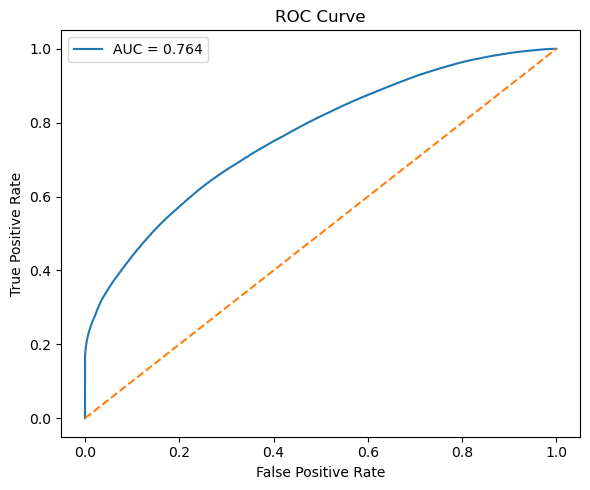

In [18]:
# Evaluate model

pred = model.predict(X_test)
proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, pred, zero_division=0))
print("Confusion matrix:")
print(confusion_matrix(y_test, pred))

fpr, tpr, _ = roc_curve(y_test, proba)
roc_auc = auc(fpr, tpr)

fig = plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()